In [1]:
# https://www.kaggle.com/datasets/gpiosenka/sports-classification/code

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import os

torch.manual_seed(42)

In [3]:
print("torch version:", torch.__version__)
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("No GPU found. Using CPU.")
    device = torch.device("cpu")

torch version: 2.11.0
No GPU found. Using CPU.


In [4]:
data_dir = "archive"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225]) # https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)


In [5]:
print(train_dataset.classes)

['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault', 'polo', 'pommel horse', 'rings', 'rock climbing', 'roller 

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

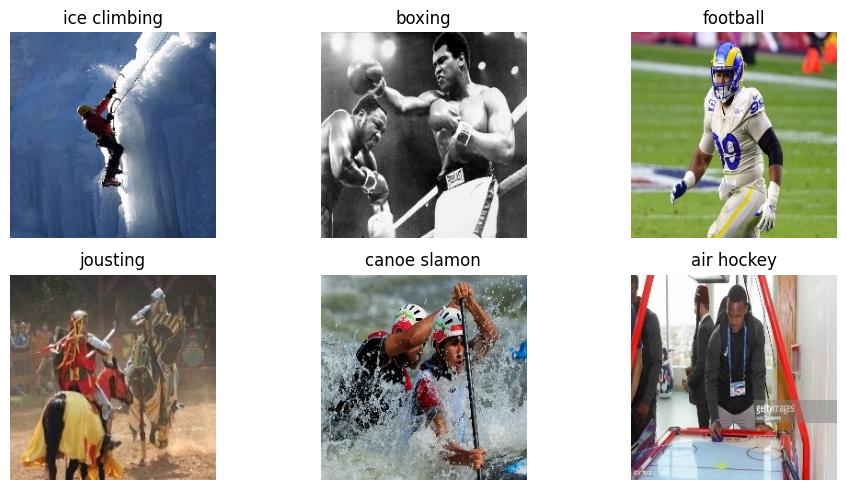

In [7]:
images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

images = images * std + mean

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# ResNet

In [8]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

In [9]:
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1} ...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.4f}%")

Epoch 1 ...
Epoch 1/10 - Loss: 1.8612 - Train Acc: 0.5154 - Val Acc: 0.6300
Epoch 2 ...
Epoch 2/10 - Loss: 0.8654 - Train Acc: 0.7536 - Val Acc: 0.7620
Epoch 3 ...
Epoch 3/10 - Loss: 0.4957 - Train Acc: 0.8563 - Val Acc: 0.8000
Epoch 4 ...
Epoch 4/10 - Loss: 0.3328 - Train Acc: 0.8971 - Val Acc: 0.8100
Epoch 5 ...
Epoch 5/10 - Loss: 0.2141 - Train Acc: 0.9356 - Val Acc: 0.8120
Epoch 6 ...
Epoch 6/10 - Loss: 0.2204 - Train Acc: 0.9313 - Val Acc: 0.7920
Epoch 7 ...
Epoch 7/10 - Loss: 0.1523 - Train Acc: 0.9546 - Val Acc: 0.8300
Epoch 8 ...
Epoch 8/10 - Loss: 0.1955 - Train Acc: 0.9405 - Val Acc: 0.8580
Epoch 9 ...
Epoch 9/10 - Loss: 0.1301 - Train Acc: 0.9587 - Val Acc: 0.8360
Epoch 10 ...
Epoch 10/10 - Loss: 0.1663 - Train Acc: 0.9495 - Val Acc: 0.7880
Test Accuracy: 78.0000%


## Add Data Agumantation

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1} ...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.4f}%")

Epoch 1 ...
Epoch 1/10 - Loss: 2.4229 - Train Acc: 0.3874 - Val Acc: 0.5580
Epoch 2 ...
Epoch 2/10 - Loss: 1.3232 - Train Acc: 0.6282 - Val Acc: 0.6120
Epoch 3 ...
Epoch 3/10 - Loss: 0.9754 - Train Acc: 0.7140 - Val Acc: 0.7620
Epoch 4 ...
Epoch 4/10 - Loss: 0.7817 - Train Acc: 0.7704 - Val Acc: 0.7820
Epoch 5 ...
Epoch 5/10 - Loss: 0.6650 - Train Acc: 0.8014 - Val Acc: 0.8260
Epoch 6 ...
Epoch 6/10 - Loss: 0.5484 - Train Acc: 0.8345 - Val Acc: 0.7960
Epoch 7 ...
Epoch 7/10 - Loss: 0.4910 - Train Acc: 0.8497 - Val Acc: 0.7980
Epoch 8 ...
Epoch 8/10 - Loss: 0.4415 - Train Acc: 0.8643 - Val Acc: 0.8160
Epoch 9 ...
Epoch 9/10 - Loss: 0.3860 - Train Acc: 0.8790 - Val Acc: 0.8420
Epoch 10 ...
Epoch 10/10 - Loss: 0.3293 - Train Acc: 0.8973 - Val Acc: 0.8300
Test Accuracy: 89.4000%


## Adam to SGD

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1} ...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.4f}%")

Epoch 1 ...
Epoch 1/10 - Loss: 1.6407 - Train Acc: 0.5713 - Val Acc: 0.7560
Epoch 2 ...
Epoch 2/10 - Loss: 0.7189 - Train Acc: 0.7875 - Val Acc: 0.8400
Epoch 3 ...
Epoch 3/10 - Loss: 0.4929 - Train Acc: 0.8545 - Val Acc: 0.8300
Epoch 4 ...
Epoch 4/10 - Loss: 0.3984 - Train Acc: 0.8782 - Val Acc: 0.8840
Epoch 5 ...
Epoch 5/10 - Loss: 0.3118 - Train Acc: 0.9047 - Val Acc: 0.9200
Epoch 6 ...
Epoch 6/10 - Loss: 0.2171 - Train Acc: 0.9335 - Val Acc: 0.9160
Epoch 7 ...
Epoch 7/10 - Loss: 0.1785 - Train Acc: 0.9434 - Val Acc: 0.9160
Epoch 8 ...
Epoch 8/10 - Loss: 0.1472 - Train Acc: 0.9540 - Val Acc: 0.9200
Epoch 9 ...
Epoch 9/10 - Loss: 0.1268 - Train Acc: 0.9601 - Val Acc: 0.9040
Epoch 10 ...
Epoch 10/10 - Loss: 0.1131 - Train Acc: 0.9644 - Val Acc: 0.9280
Test Accuracy: 93.8000%


## Add optimizer scheduler

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.1)
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1} ...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - LR: {optimizer.param_groups[0]['lr']:.6f} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.4f}%")

Epoch 1 ...
Epoch 1/10 - LR: 0.010000 - Loss: 1.6350 - Train Acc: 0.5707 - Val Acc: 0.7680
Epoch 2 ...
Epoch 2/10 - LR: 0.010000 - Loss: 0.7262 - Train Acc: 0.7868 - Val Acc: 0.8320
Epoch 3 ...
Epoch 3/10 - LR: 0.010000 - Loss: 0.5248 - Train Acc: 0.8438 - Val Acc: 0.8660
Epoch 4 ...
Epoch 4/10 - LR: 0.010000 - Loss: 0.3715 - Train Acc: 0.8873 - Val Acc: 0.8620
Epoch 5 ...
Epoch 5/10 - LR: 0.010000 - Loss: 0.2872 - Train Acc: 0.9088 - Val Acc: 0.9080
Epoch 6 ...
Epoch 6/10 - LR: 0.010000 - Loss: 0.2346 - Train Acc: 0.9277 - Val Acc: 0.8880
Epoch 7 ...
Epoch 7/10 - LR: 0.010000 - Loss: 0.1815 - Train Acc: 0.9448 - Val Acc: 0.9220
Epoch 8 ...
Epoch 8/10 - LR: 0.010000 - Loss: 0.1499 - Train Acc: 0.9539 - Val Acc: 0.8860
Epoch 9 ...
Epoch 9/10 - LR: 0.010000 - Loss: 0.1397 - Train Acc: 0.9571 - Val Acc: 0.9260
Epoch 10 ...
Epoch 10/10 - LR: 0.010000 - Loss: 0.0971 - Train Acc: 0.9713 - Val Acc: 0.9260
Test Accuracy: 94.4000%


# EfficientNet 

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/roxana/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████████████████████████████████| 20.5M/20.5M [00:03<00:00, 6.19MB/s]


In [14]:
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(train_dataset.classes))
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.1)
num_epochs = 5
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1} ...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - LR: {optimizer.param_groups[0]['lr']:.6f} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
    scheduler.step(val_acc)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.4f}%")

Epoch 1 ...
Epoch 1/5 - LR: 0.010000 - Loss: 1.7112 - Train Acc: 0.6139 - Val Acc: 0.9180
Epoch 2 ...
Epoch 2/5 - LR: 0.010000 - Loss: 0.4120 - Train Acc: 0.8832 - Val Acc: 0.9540
Epoch 3 ...
Epoch 3/5 - LR: 0.010000 - Loss: 0.2466 - Train Acc: 0.9291 - Val Acc: 0.9720
Epoch 4 ...
Epoch 4/5 - LR: 0.010000 - Loss: 0.1634 - Train Acc: 0.9538 - Val Acc: 0.9480
Epoch 5 ...
Epoch 5/5 - LR: 0.010000 - Loss: 0.1237 - Train Acc: 0.9651 - Val Acc: 0.9600
Test Accuracy: 97.6000%


In [15]:
torch.save(model.state_dict(), "model_checkpoint.pth")

In [16]:
print("Number of classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes[:10], "...")

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Number of classes: 100
Classes: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling'] ...
Training images: 13492
Validation images: 500
Test images: 500


In [8]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": [
        "ResNet18 baseline (Adam)",
        "ResNet18 + data augmentation",
        "ResNet18 + SGD",
        "ResNet18 + SGD + scheduler",
        "EfficientNet-B0"
    ],
    "Test Accuracy (%)": [78.0, 89.4, 93.8, 94.4, 97.6],
    "Main Change": [
        "Baseline transfer learning",
        "Added random crop/flip/rotation",
        "Changed optimizer from Adam to SGD",
        "Added learning-rate scheduler",
        "Changed architecture to EfficientNet-B0"
    ]
})

results

,Experiment,Test Accuracy (%),Main Change
0,ResNet18 baseline (Adam),78.0,Baseline transfer learning
1,ResNet18 + data augmentation,89.4,Added random crop/flip/rotation
2,ResNet18 + SGD,93.8,Changed optimizer from Adam to SGD
3,ResNet18 + SGD + scheduler,94.4,Added learning-rate scheduler
4,EfficientNet-B0,97.6,Changed architecture to EfficientNet-B0


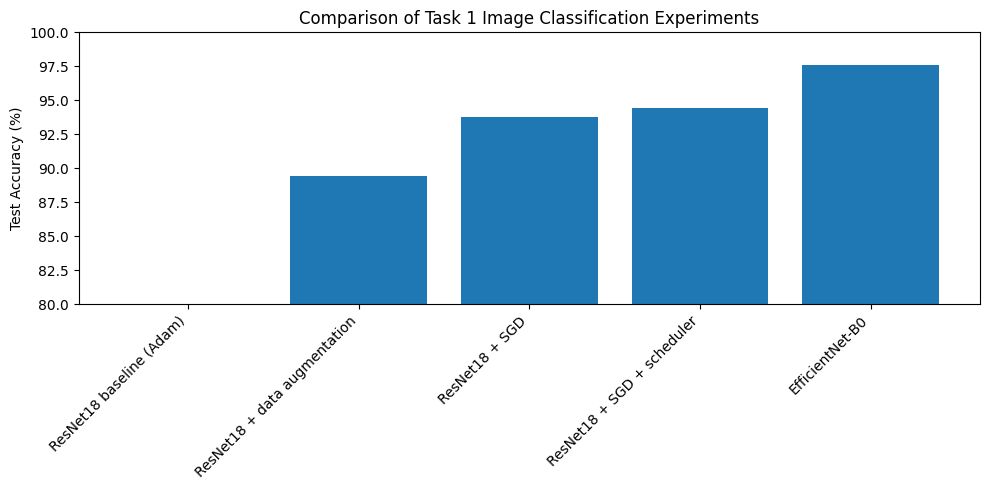

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results["Experiment"], results["Test Accuracy (%)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Task 1 Image Classification Experiments")
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

                       precision    recall  f1-score   support

           air hockey       1.00      1.00      1.00         5
      ampute football       1.00      1.00      1.00         5
              archery       1.00      1.00      1.00         5
        arm wrestling       1.00      1.00      1.00         5
         axe throwing       1.00      1.00      1.00         5
         balance beam       1.00      1.00      1.00         5
        barell racing       1.00      1.00      1.00         5
             baseball       1.00      1.00      1.00         5
           basketball       1.00      1.00      1.00         5
       baton twirling       1.00      1.00      1.00         5
            bike polo       1.00      1.00      1.00         5
            billiards       1.00      1.00      1.00         5
                  bmx       1.00      0.80      0.89         5
              bobsled       1.00      1.00      1.00         5
              bowling       1.00      1.00      1.00  

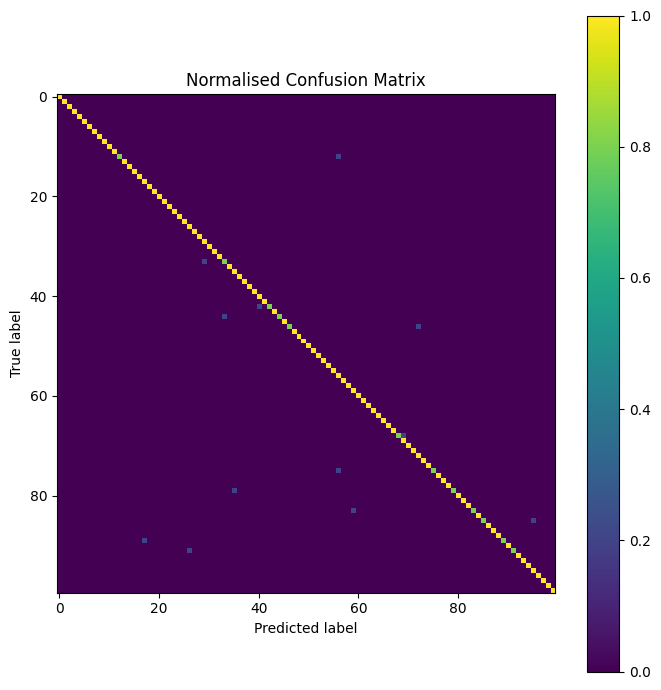

In [29]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 7))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalised Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

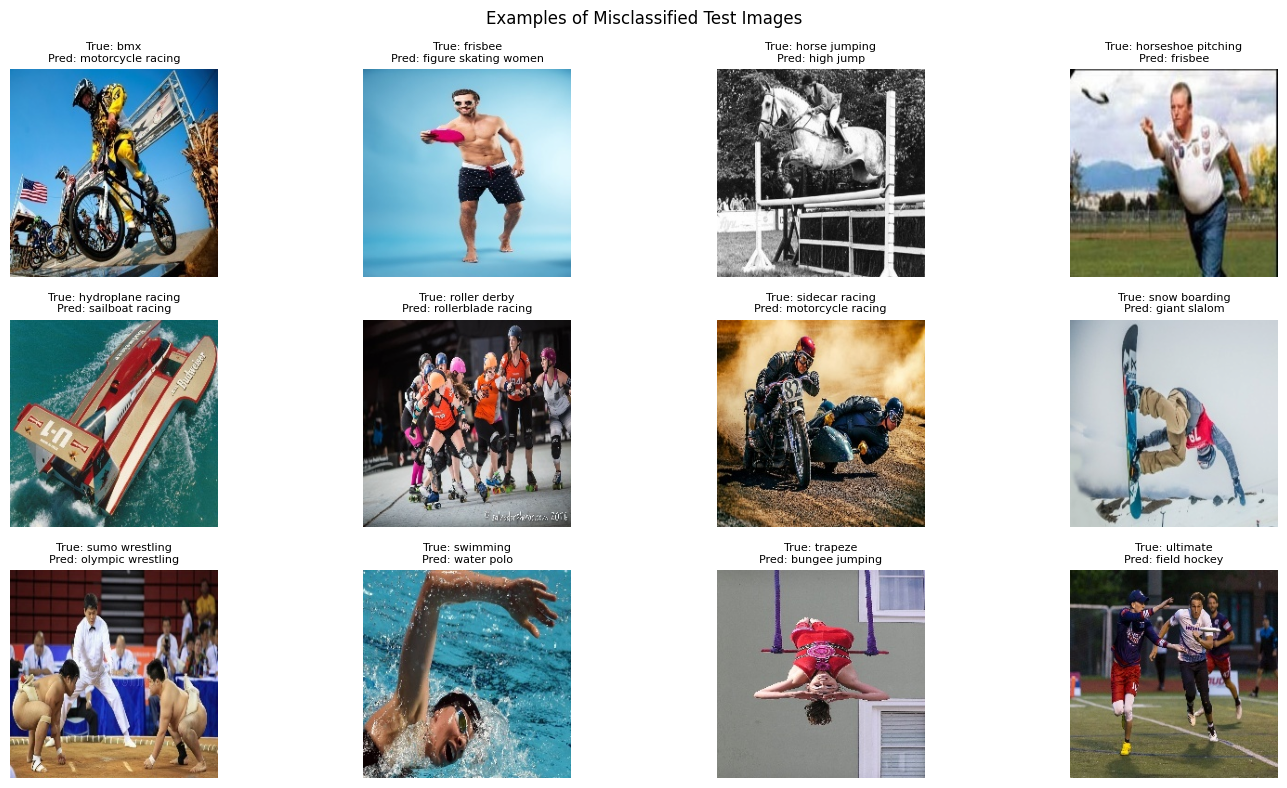

In [23]:
incorrect_images = []
incorrect_true = []
incorrect_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        labels_gpu = labels.to(device)

        outputs = model(images_gpu)
        _, preds = torch.max(outputs, 1)

        for img, true_label, pred_label in zip(images, labels, preds.cpu()):
            if true_label != pred_label:
                incorrect_images.append(img)
                incorrect_true.append(true_label.item())
                incorrect_pred.append(pred_label.item())

            if len(incorrect_images) >= 12:
                break

        if len(incorrect_images) >= 12:
            break

plt.figure(figsize=(15, 8))

for i in range(len(incorrect_images)):
    img = incorrect_images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {test_dataset.classes[incorrect_true[i]]}\nPred: {test_dataset.classes[incorrect_pred[i]]}",
        fontsize=8
    )

plt.suptitle("Examples of Misclassified Test Images")
plt.tight_layout()
plt.show()

In [24]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters in final model:", count_parameters(model))

Trainable parameters in final model: 4135648
